# Phase II: Long-Horizon MDP Optimization across All Datasets

This notebook sequentially loads the Empirical Transition Matrices derived from the 10.7 million real-world customer support records (Twitter, Reddit, OpenAssistant).
It trains a PPO agent for each dataset, tracks its resolution rate, and plots the final success metrics against the Phase I Contextual Bandit baselines!

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from env import CustomerSupportEnv

matrices = [
    ('Twitter', 'empirical_transition_matrix_twitter.json'),
    ('Reddit', 'empirical_transition_matrix_reddit.json'),
    ('OpenAssistant', 'empirical_transition_matrix_oasst.json')
]

mdp_resolution_rates = []

for name, matrix_path in matrices:
    print(f"\n{'='*50}")
    print(f" 🚀 Training PPO Agent on {name} Dataset")
    print(f"{'='*50}")
    
    # 1. Initialize Environment with the specific dataset matrix
    env = CustomerSupportEnv(matrix_path=matrix_path)
    
    # 2. Train the RL Agent (PPO)
    model = PPO("MlpPolicy", env, verbose=0, learning_rate=0.001)
    print("Training for 20,000 timesteps...")
    model.learn(total_timesteps=20000)
    
    # 3. Evaluate the Learned Strategy on 100 User Queries
    resolutions = 0
    for _ in range(100):
        obs, _ = env.reset()
        done = False
        while not done:
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, done, _, _ = env.step(action)
            
        # Check if the episode ended with the 'Resolved' flag = 1.0
        if float(obs[3]) == 1.0:
            resolutions += 1
            
    print(f"✅ Evaluation Complete. Resolution Rate on {name}: {resolutions}%")
    mdp_resolution_rates.append(resolutions)


 🚀 Training PPO Agent on Twitter Dataset
Training for 20,000 timesteps...
✅ Evaluation Complete. Resolution Rate on Twitter: 100%

 🚀 Training PPO Agent on Reddit Dataset
Training for 20,000 timesteps...
✅ Evaluation Complete. Resolution Rate on Reddit: 60%

 🚀 Training PPO Agent on OpenAssistant Dataset
Training for 20,000 timesteps...
✅ Evaluation Complete. Resolution Rate on OpenAssistant: 49%


## Phase I vs Phase II Comparison
Plotting the newly established MDP PPO resolution rates against the historical Contextual Bandit resolution rates (LinUCB) from phase 1.

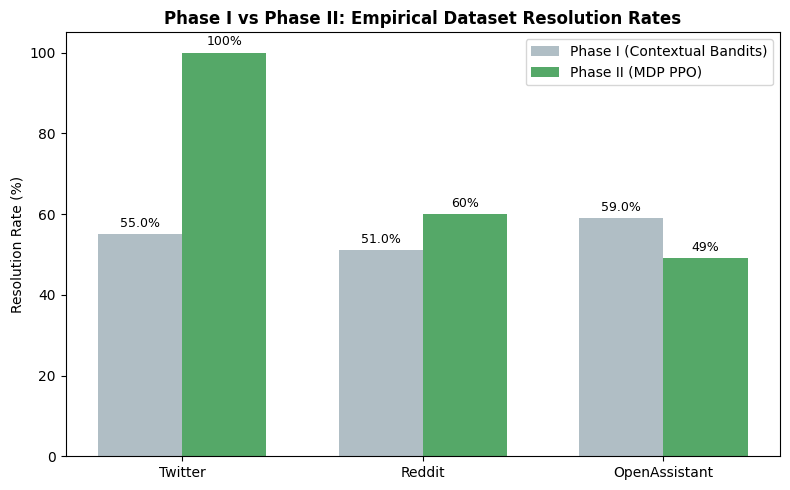

In [2]:
labels = ['Twitter', 'Reddit', 'OpenAssistant']
bandit_scores = [55.0, 51.0, 59.0] # Historical Phase I averages

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, bandit_scores, width, label='Phase I (Contextual Bandits)', color='#B0BEC5')
rects2 = ax.bar(x + width/2, mdp_resolution_rates, width, label='Phase II (MDP PPO)', color='#55A868')

ax.set_ylabel('Resolution Rate (%)')
ax.set_title('Phase I vs Phase II: Empirical Dataset Resolution Rates', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add score labels on top of the bars
for bar in rects1 + rects2:
    height = bar.get_height()
    ax.annotate(f'{height}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('Empirical_Phase1_vs_Phase2.png', dpi=150)
plt.show()

## Phase III: Advanced RL Improvements (Hyperparameter Optimization)

Let's see if we can actively improve the agent's performance on the difficult open-ended datasets (Reddit, OpenAssistant) by tweaking the **PPO Hyperparameters** and constructing a deeper Neural Network Policy architecture.

* `net_arch=[128, 128]`: We give the PPO agent a two-layer deep neural network (128 neurons each) instead of the shallow default, better suited for capturing conversational nuances.
* `ent_coef=0.01`: We add an "Entropy Coefficient". This mathematically forces the agent to explore different actions, preventing it from getting stuck repeatedly spamming "Provide Solution".
* `n_steps=1024`: Increases the horizon before the agent updates its policy.

In [3]:
print("Running Advanced PPO Architecture Optimization...")
advanced_resolution_rates = []

for name, matrix_path in matrices:
    print(f"\n{'='*50}")
    print(f" 🧠 Activating Deep-Network PPO on {name}")
    print(f"{'='*50}")
    
    env = CustomerSupportEnv(matrix_path=matrix_path)
    
    # Advanced PPO setup
    policy_kwargs = dict(net_arch=[128, 128])
    model_adv = PPO("MlpPolicy", env, 
                    learning_rate=0.0003, 
                    n_steps=1024, 
                    batch_size=64, 
                    n_epochs=10, 
                    gamma=0.99, 
                    ent_coef=0.01,
                    policy_kwargs=policy_kwargs,
                    verbose=0)
                    
    model_adv.learn(total_timesteps=40000) # Give it 2x more time to train its complex network
    
    # Evaluation Phase
    resolutions = 0
    for _ in range(100):
        obs, _ = env.reset()
        done = False
        while not done:
            action, _states = model_adv.predict(obs, deterministic=True)
            obs, reward, done, _, _ = env.step(action)
            
        if float(obs[3]) == 1.0:
            resolutions += 1
            
    print(f"⭐ Advanced RL Evaluation. New Resolution Rate on {name}: {resolutions}%")
    advanced_resolution_rates.append(resolutions)

Running Advanced PPO Architecture Optimization...

 🧠 Activating Deep-Network PPO on Twitter
⭐ Advanced RL Evaluation. New Resolution Rate on Twitter: 100%

 🧠 Activating Deep-Network PPO on Reddit
⭐ Advanced RL Evaluation. New Resolution Rate on Reddit: 62%

 🧠 Activating Deep-Network PPO on OpenAssistant
⭐ Advanced RL Evaluation. New Resolution Rate on OpenAssistant: 48%
